<a href="https://colab.research.google.com/github/adenurchalisa/Automatic-Photo-Clustering-System-Optimization-HDBSCAN/blob/main/notebooks/13_CGA_NoiseSingleton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 13: NT-CGA — Noise-Targeted Cluster-Guided Gaussian Augmentation

## Latar Belakang & Motivasi

Notebook 12 menunjukkan bahwa **CGA standar tidak efektif** pada dataset ini:
- Dari 54 cluster baseline, hanya **1 cluster** yang memenuhi threshold minority (≤30 anggota)
- Hasil terbaik CGA: **+0.2% coverage** — hampir tidak berarti

**Root cause:** Few-shot problem di dataset ini tidak termanifestasi sebagai *minority cluster*, melainkan sebagai *noise points*. Individu yang muncul sedikit tidak pernah membentuk cluster — mereka langsung menjadi noise (5,565 points = 43.8%).

## Solusi: NT-CGA (Noise-Targeted CGA)

Berbeda dari CGA standar yang augment cluster kecil, **NT-CGA langsung menyasar noise points** yang terklasifikasi sebagai *probable singletons* (dari analisis DNCN di Notebook 11):

### Algoritma:
```
Untuk setiap probable singleton noise point x_i:
    1. Estimasi σ_local dari k nearest clustered neighbors ke x_i
    2. Generate n_synthetic sampel sintetis:
       x_syn = x_i + α · σ_local · ε,  ε ~ N(0, I)
    3. Validasi: hanya simpan yang di bawah radius wajar dari x_i
```

### Formula:
$$\mathbf{x}_{syn} = \mathbf{x}_i + \alpha \cdot \boldsymbol{\sigma}_{local} \cdot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

Di mana:
- $\mathbf{x}_i$ = noise point (probable singleton)
- $\boldsymbol{\sigma}_{local}$ = std per dimensi dari $k$ nearest *clustered* neighbors ke $\mathbf{x}_i$
- $\alpha$ = scale factor (hyperparameter ablasi)
- $\epsilon$ = random noise $\sim \mathcal{N}(0, I)$ (GPU)

### Perbedaan vs CGA Standar (NB12):

| Aspek | CGA (NB12) | NT-CGA (NB13) |
|-------|------------|---------------|
| Target | Minority clusters (ada) | Noise singletons (baru) |
| σ estimasi | Std dalam cluster | Std dari k-NN clustered neighbors |
| Pusat sampling | Centroid cluster | Noise point itu sendiri |
| mcs re-cluster | Sama dengan baseline (15) | Lebih rendah (3–7) |
| Potensi dampak | Kecil (1 target) | Besar (1,391 targets) |

## Alur Eksperimen

```
Embeddings (12,715 × 512)
        ↓
Baseline Clustering (Correlation, mcs=15, ms=70)
        ↓
Klasifikasi Noise via DNCN (re-compute dari NB11)
        ↓
Identifikasi Probable Singletons (DNCN < Q25)
        ↓
NT-CGA: Gaussian Sampling sekitar setiap singleton [GPU]
        ↓
Gabungkan: Original + Synthetic Embeddings
        ↓
Re-clustering HDBSCAN (mcs lebih rendah)
        ↓
Evaluasi & Ablation Study (α × n_synthetic × mcs_recluster)
```


## Cell 1 — Instalasi & Imports

In [1]:
!pip install hdbscan cupy-cuda12x -q

import importlib.metadata
import numpy as np
import pickle
import time
import os
import warnings
from collections import Counter
from datetime import datetime
from itertools import product

import cupy as cp
import hdbscan
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator

from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

gpu_name = cp.cuda.runtime.getDeviceProperties(0)['name'].decode()
gpu_mem  = cp.cuda.runtime.getDeviceProperties(0)['totalGlobalMem'] / (1024**3)
hdbscan_version = importlib.metadata.version('hdbscan')
print(f"✅ GPU: {gpu_name}  ({gpu_mem:.1f} GB VRAM)")
print(f"✅ CuPy version : {cp.__version__}")
print(f"✅ HDBSCAN version: {hdbscan_version}")
print("✅ Semua library berhasil dimuat")

✅ GPU: Tesla T4  (14.6 GB VRAM)
✅ CuPy version : 14.0.1
✅ HDBSCAN version: 0.8.41
✅ Semua library berhasil dimuat


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


## Cell 2 — Konfigurasi

In [2]:
class Config:
    # ─── Path ────────────────────────────────────────────────────────
    EMBEDDINGS_PATH = '/content/drive/MyDrive/OTW S.KOM/Embeddings/embeddings_data.pkl'
    RESULTS_DIR     = '/content/drive/MyDrive/OTW S.KOM/Results/'
    PLOTS_DIR       = '/content/drive/MyDrive/OTW S.KOM/Results/Plots/'

    # ─── Baseline HDBSCAN (sama dengan NB11 & NB12) ──────────────────
    BASELINE_PARAMS = {
        'metric'           : 'correlation',
        'min_cluster_size' : 15,
        'min_samples'      : 70,
        'method'           : 'eom',
    }

    # ─── DNCN Singleton threshold ─────────────────────────────────────
    # Noise points dengan DNCN < Q25 dianggap probable singletons.
    # Q25 dari Notebook 11: 16.98
    DNCN_Q25 = 16.98

    # k-NN untuk estimasi σ_local
    # Gunakan 10 nearest clustered neighbors untuk estimasi std lokal
    K_NEIGHBORS = 10

    # ─── NT-CGA Hyperparameters (Ablation) ───────────────────────────
    ALPHA_LIST       = [0.3, 0.5, 1.0]   # scale factor variasi Gaussian
    N_SYNTHETIC_LIST = [5, 10, 15]        # sampel sintetis per singleton

    # ─── Re-clustering params (mcs lebih rendah!) ────────────────────
    # Dengan n_synthetic sampel per singleton, kita perlu mcs < n_synthetic
    # agar cluster baru bisa terbentuk
    MCS_RECLUSTER_LIST = [3, 5, 7]        # ablasi mcs untuk re-clustering
    MS_RECLUSTER       = 1                # min_samples rendah untuk sensitivitas max

    # Seed reproducibility
    SEED = 42

    # Batch size sampling sintetis (batching agar VRAM tidak penuh)
    BATCH_SIZE = 200


cp.random.seed(Config.SEED)
np.random.seed(Config.SEED)

print("=" * 60)
print("✅ CONFIG LOADED")
print("=" * 60)
print(f"\n  DNCN singleton threshold : < {Config.DNCN_Q25} (Q25 dari NB11)")
print(f"  k-NN untuk σ_local       : {Config.K_NEIGHBORS}")
print(f"  Alpha values (ablasi)    : {Config.ALPHA_LIST}")
print(f"  N synthetic (ablasi)     : {Config.N_SYNTHETIC_LIST}")
print(f"  MCS re-cluster (ablasi)  : {Config.MCS_RECLUSTER_LIST}")
print(f"  MS re-cluster (fixed)    : {Config.MS_RECLUSTER}")
total = len(Config.ALPHA_LIST) * len(Config.N_SYNTHETIC_LIST) * len(Config.MCS_RECLUSTER_LIST)
print(f"  Total kombinasi ablasi   : {total}")

✅ CONFIG LOADED

  DNCN singleton threshold : < 16.98 (Q25 dari NB11)
  k-NN untuk σ_local       : 10
  Alpha values (ablasi)    : [0.3, 0.5, 1.0]
  N synthetic (ablasi)     : [5, 10, 15]
  MCS re-cluster (ablasi)  : [3, 5, 7]
  MS re-cluster (fixed)    : 1
  Total kombinasi ablasi   : 27


## Cell 3 — Load Data & Reproduce Baseline

In [3]:
from google.colab import drive

print("=" * 60)
print("📁 LOAD DATA")
print("=" * 60)

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print("✅ Google Drive sudah ter-mount")

os.makedirs(Config.RESULTS_DIR, exist_ok=True)
os.makedirs(Config.PLOTS_DIR, exist_ok=True)

# Load embeddings
with open(Config.EMBEDDINGS_PATH, 'rb') as f:
    data = pickle.load(f)

embeddings = np.array(data['embeddings']).astype('float32')
metadata   = data['metadata']

print(f"\n✅ Embeddings loaded: {embeddings.shape}")
print(f"   Metadata: {len(metadata)} entries")

# Transfer ke GPU
print(f"\n⏳ Transfer embeddings ke GPU...")
t = time.time()
embeddings_gpu = cp.array(embeddings)
print(f"   ✅ GPU array: {embeddings_gpu.shape} ({time.time()-t:.2f}s)")
print(f"   VRAM: {embeddings_gpu.nbytes / (1024**2):.1f} MB")

# Reproduce baseline clustering
print(f"\n⏳ Reproducing baseline (Correlation, mcs=15, ms=70)...")
t = time.time()
clusterer_baseline = hdbscan.HDBSCAN(
    min_cluster_size         = Config.BASELINE_PARAMS['min_cluster_size'],
    min_samples              = Config.BASELINE_PARAMS['min_samples'],
    cluster_selection_method = Config.BASELINE_PARAMS['method'],
    metric                   = Config.BASELINE_PARAMS['metric'],
)
labels_baseline = clusterer_baseline.fit_predict(embeddings)
elapsed = time.time() - t

n_clusters_base = len(set(labels_baseline)) - 1
n_noise_base    = int((labels_baseline == -1).sum())
coverage_base   = float((labels_baseline != -1).sum() / len(labels_baseline))

# Pisahkan embeddings: clustered vs noise
clustered_mask = labels_baseline != -1
noise_mask     = labels_baseline == -1

embeddings_clustered = embeddings[clustered_mask]   # (N_clustered, 512)
embeddings_noise     = embeddings[noise_mask]        # (N_noise, 512)
noise_indices        = np.where(noise_mask)[0]       # original indices noise

print(f"   ✅ Selesai ({elapsed:.2f}s)")
print(f"""
  ┌──────────────────────────────────────────┐
  │  BASELINE RESULTS                        │
  ├──────────────────────────────────────────┤
  │  Clusters     : {n_clusters_base:<25}│
  │  Noise        : {n_noise_base:<8,} ({1-coverage_base:.1%})            │
  │  Coverage     : {coverage_base:.1%}                       │
  │  Clustered    : {int(clustered_mask.sum()):<8,}                      │
  └──────────────────────────────────────────┘
""")

📁 LOAD DATA
Mounted at /content/drive

✅ Embeddings loaded: (12715, 512)
   Metadata: 12715 entries

⏳ Transfer embeddings ke GPU...
   ✅ GPU array: (12715, 512) (0.02s)
   VRAM: 24.8 MB

⏳ Reproducing baseline (Correlation, mcs=15, ms=70)...
   ✅ Selesai (34.99s)

  ┌──────────────────────────────────────────┐
  │  BASELINE RESULTS                        │
  ├──────────────────────────────────────────┤
  │  Clusters     : 54                       │
  │  Noise        : 5,565    (43.8%)            │
  │  Coverage     : 56.2%                       │
  │  Clustered    : 7,150                         │
  └──────────────────────────────────────────┘



## Cell 4 — Klasifikasi Noise via DNCN

Re-compute Distance to Nearest Clustered Neighbor (DNCN) untuk semua noise points.
Menggunakan threshold Q25 dari Notebook 11 (DNCN < 16.98) untuk mengidentifikasi probable singletons.

**Probable singleton** = noise point yang sebenarnya dekat dengan cluster yang ada — kemungkinan besar adalah individu genuine yang tidak punya cukup sampel untuk membentuk cluster sendiri.

In [4]:
print("=" * 60)
print("📊 KLASIFIKASI NOISE VIA DNCN")
print("=" * 60)

print(f"\n⏳ Menghitung DNCN untuk {len(embeddings_noise):,} noise points...")
print(f"   (1-NN dari {len(embeddings_clustered):,} clustered embeddings, Euclidean)")

t = time.time()
# Gunakan sklearn NearestNeighbors untuk efisiensi
nn = NearestNeighbors(n_neighbors=Config.K_NEIGHBORS, metric='euclidean', n_jobs=-1)
nn.fit(embeddings_clustered)

# Hitung jarak k-NN untuk semua noise points
dncn_distances_knn, dncn_indices_knn = nn.kneighbors(embeddings_noise)
# DNCN = jarak ke nearest clustered neighbor (kolom 0)
dncn_distances = dncn_distances_knn[:, 0]

elapsed = time.time() - t
print(f"   ✅ Selesai ({elapsed:.2f}s)")

# Statistik DNCN
dncn_q25 = float(np.percentile(dncn_distances, 25))
dncn_q75 = float(np.percentile(dncn_distances, 75))
dncn_median = float(np.median(dncn_distances))

print(f"""
  Statistik DNCN (semua noise):
  Mean   : {dncn_distances.mean():.4f}
  Median : {dncn_median:.4f}
  Std    : {dncn_distances.std():.4f}
  Q25    : {dncn_q25:.4f}  (threshold NB11: {Config.DNCN_Q25})
  Q75    : {dncn_q75:.4f}
""")

# Klasifikasi noise points
singleton_mask   = dncn_distances < Config.DNCN_Q25
borderline_mask  = (dncn_distances >= Config.DNCN_Q25) & (dncn_distances <= dncn_q75)
outlier_mask     = dncn_distances > dncn_q75

n_singleton  = singleton_mask.sum()
n_borderline = borderline_mask.sum()
n_outlier    = outlier_mask.sum()
n_noise_total = len(dncn_distances)

print(f"""
  ┌───────────────────────────────────────────────────────────────┐
  │                  KLASIFIKASI NOISE POINTS                     │
  ├───────────────────────────┬──────────────┬────────────────────┤
  │ Kategori                  │   Jumlah     │ Keterangan         │
  ├───────────────────────────┼──────────────┼────────────────────┤
  │ Probable Singleton        │ {n_singleton:<6,} ({n_singleton/n_noise_total:.0%}) │ Target NT-CGA      │
  │ (DNCN < {Config.DNCN_Q25:.2f})          │              │                    │
  ├───────────────────────────┼──────────────┼────────────────────┤
  │ Borderline                │ {n_borderline:<6,} ({n_borderline/n_noise_total:.0%}) │ Dikecualikan       │
  ├───────────────────────────┼──────────────┼────────────────────┤
  │ Probable Outlier          │ {n_outlier:<6,} ({n_outlier/n_noise_total:.0%}) │ Dikecualikan       │
  └───────────────────────────┴──────────────┴────────────────────┘
""")

# Ambil data singleton untuk NT-CGA
embeddings_singleton = embeddings_noise[singleton_mask]        # (n_singleton, 512)
knn_indices_singleton = dncn_indices_knn[singleton_mask]       # (n_singleton, K) — indeks di clustered

print(f"  ✅ NT-CGA akan memproses {n_singleton:,} probable singletons")
print(f"     Setiap singleton punya {Config.K_NEIGHBORS} clustered neighbors untuk estimasi σ_local")

📊 KLASIFIKASI NOISE VIA DNCN

⏳ Menghitung DNCN untuk 5,565 noise points...
   (1-NN dari 7,150 clustered embeddings, Euclidean)
   ✅ Selesai (0.36s)

  Statistik DNCN (semua noise):
  Mean   : 19.3627
  Median : 19.3504
  Std    : 3.6579
  Q25    : 16.9605  (threshold NB11: 16.98)
  Q75    : 22.2499


  ┌───────────────────────────────────────────────────────────────┐
  │                  KLASIFIKASI NOISE POINTS                     │
  ├───────────────────────────┬──────────────┬────────────────────┤
  │ Kategori                  │   Jumlah     │ Keterangan         │
  ├───────────────────────────┼──────────────┼────────────────────┤
  │ Probable Singleton        │ 1,395  (25%) │ Target NT-CGA      │
  │ (DNCN < 16.98)          │              │                    │
  ├───────────────────────────┼──────────────┼────────────────────┤
  │ Borderline                │ 2,779  (50%) │ Dikecualikan       │
  ├───────────────────────────┼──────────────┼────────────────────┤
  │ Probable Outli

## Cell 5 — NT-CGA Core: Gaussian Sampling sekitar Noise Singletons

Fungsi utama NT-CGA yang berjalan di GPU menggunakan CuPy.

### Perbedaan kunci dari CGA standar (NB12):
- **Pusat sampling = noise point itu sendiri** (bukan centroid cluster)
- **σ_local = std dari k nearest clustered neighbors** (bukan std dalam cluster)
- **Radius validasi = jarak DNCN** (jarak ke nearest clustered neighbor)

### Kenapa σ_local dari clustered neighbors?
Karena clustered neighbors merepresentasikan distribusi embedding yang "valid" di area tersebut. Dengan menyample dari distribusi lokal itu sekitar noise point, kita mensimulasikan embedding wajah yang sama jika dia muncul lebih banyak di area yang sama.

In [5]:
def nt_cga_gpu(
    embeddings_singleton: np.ndarray,
    embeddings_clustered: np.ndarray,
    knn_indices: np.ndarray,
    dncn_dist: np.ndarray,
    alpha: float = 0.5,
    n_synthetic: int = 10,
    seed: int = 42,
    batch_size: int = 200,
) -> np.ndarray:
    """
    NT-CGA: Noise-Targeted Cluster-Guided Gaussian Augmentation.

    Untuk setiap probable singleton noise point:
      1. Estimasi σ_local dari k nearest clustered neighbors (CPU)
      2. Generate n_synthetic sampel Gaussian sekitar singleton (GPU)
      3. Validasi: hanya simpan yang dalam radius DNCN × 1.5

    Parameters
    ----------
    embeddings_singleton : (n_sing, D) — probable singleton noise embeddings (CPU)
    embeddings_clustered : (n_clust, D) — semua clustered embeddings (CPU)
    knn_indices          : (n_sing, K) — indeks k-NN di embeddings_clustered
    dncn_dist            : (n_sing,) — jarak ke nearest clustered neighbor
    alpha                : scale factor variasi
    n_synthetic          : jumlah sampel sintetis per singleton
    seed                 : reproducibility
    batch_size           : proses batch singleton untuk hemat VRAM

    Returns
    -------
    syn_embs : (M, D) CPU array — seluruh synthetic embeddings yang valid
    """
    cp.random.seed(seed)
    D = embeddings_singleton.shape[1]
    n_sing = len(embeddings_singleton)

    all_syn = []

    for batch_start in range(0, n_sing, batch_size):
        batch_end  = min(batch_start + batch_size, n_sing)
        batch_embs = embeddings_singleton[batch_start:batch_end]   # (B, D)
        batch_knn  = knn_indices[batch_start:batch_end]            # (B, K)
        batch_dncn = dncn_dist[batch_start:batch_end]              # (B,)
        B = len(batch_embs)

        # ── Step 1: Estimasi σ_local dari k-NN (CPU) ─────────────────
        # Untuk setiap singleton, ambil embedding K clustered neighbors-nya
        # Shape: (B, K, D)
        neighbor_embs = embeddings_clustered[batch_knn]             # (B, K, D)
        # σ_local per dimensi: std di antara K neighbors → (B, D)
        sigma_local   = neighbor_embs.std(axis=1)                   # (B, D)
        # Hindari sigma = 0
        sigma_local   = np.where(sigma_local < 1e-8, 1e-8, sigma_local)

        # Transfer ke GPU
        batch_gpu  = cp.array(batch_embs)    # (B, D)
        sigma_gpu  = cp.array(sigma_local)   # (B, D)
        dncn_gpu   = cp.array(batch_dncn)    # (B,)

        # ── Step 2: Generate n_synthetic sampel per singleton (GPU) ──
        # epsilon: (B, n_synthetic, D)
        epsilon = cp.random.randn(B, n_synthetic, D).astype(cp.float32)

        # x_syn[b, s] = x_i[b] + α * σ_local[b] * ε[b, s]
        # Shape: (B, n_synthetic, D)
        x_syn = (batch_gpu[:, cp.newaxis, :]
                 + alpha * sigma_gpu[:, cp.newaxis, :] * epsilon)

        # ── Step 3: Boundary validation (GPU) ────────────────────────
        # Jarak setiap synthetic ke singleton asalnya
        diff        = x_syn - batch_gpu[:, cp.newaxis, :]           # (B, n_syn, D)
        syn_dists   = cp.linalg.norm(diff, axis=2)                  # (B, n_syn)

        # Radius = 1.5 × DNCN (memberi kelonggaran 50% dari jarak ke cluster terdekat)
        radius      = dncn_gpu * 1.5                                 # (B,)
        valid_mask  = syn_dists <= radius[:, cp.newaxis]             # (B, n_syn)

        # Flatten valid synthetic samples → (M_batch, D)
        x_syn_flat  = x_syn.reshape(-1, D)                          # (B*n_syn, D)
        valid_flat  = valid_mask.reshape(-1)                         # (B*n_syn,)
        x_valid     = x_syn_flat[valid_flat]                         # (M_batch, D)

        if x_valid.shape[0] > 0:
            all_syn.append(cp.asnumpy(x_valid).astype('float32'))

        # Bersihkan VRAM batch
        del batch_gpu, sigma_gpu, dncn_gpu, epsilon, x_syn, diff, syn_dists, valid_mask
        cp.get_default_memory_pool().free_all_blocks()

    if len(all_syn) == 0:
        return np.empty((0, D), dtype='float32')

    return np.vstack(all_syn)   # (M_total, D)


# ── Sanity Check ───────────────────────────────────────────────────────────
print("=" * 60)
print("🧪 SANITY CHECK: NT-CGA pada 5 singletons pertama")
print("=" * 60)

test_syn = nt_cga_gpu(
    embeddings_singleton = embeddings_singleton[:5],
    embeddings_clustered = embeddings_clustered,
    knn_indices          = knn_indices_singleton[:5],
    dncn_dist            = dncn_distances[singleton_mask][:5],
    alpha                = 0.5,
    n_synthetic          = 5,
    seed                 = Config.SEED,
    batch_size           = 5,
)

print(f"""
  Input  : 5 singletons × 5 synthetic = 25 requested
  Output : {len(test_syn)} valid synthetic samples
  Shape  : {test_syn.shape}
  Dtype  : {test_syn.dtype}
  Range  : [{test_syn.min():.4f}, {test_syn.max():.4f}]
""")
print("✅ Sanity check passed — NT-CGA berfungsi dengan benar")

🧪 SANITY CHECK: NT-CGA pada 5 singletons pertama

  Input  : 5 singletons × 5 synthetic = 25 requested
  Output : 25 valid synthetic samples
  Shape  : (25, 512)
  Dtype  : float32
  Range  : [-2.3672, 2.5852]

✅ Sanity check passed — NT-CGA berfungsi dengan benar


## Cell 6 — Ablation Study: α × n_synthetic × mcs_recluster

Grid search 3D:
- **α** ∈ {0.3, 0.5, 1.0}: lebar distribusi Gaussian
- **n_synthetic** ∈ {5, 10, 15}: sampel per singleton
- **mcs_recluster** ∈ {3, 5, 7}: min_cluster_size untuk re-clustering

> **Logika:** Dengan n_synthetic=5, mcs=3 → setiap singleton dikelilingi 5 sampel sintetis. HDBSCAN butuh minimal mcs=3 titik berdekatan → cluster baru bisa terbentuk.

In [6]:
print("=" * 70)
print("🔬 ABLATION STUDY: α × n_synthetic × mcs_recluster")
print("=" * 70)

n_sing = len(embeddings_singleton)
total_combos = len(Config.ALPHA_LIST) * len(Config.N_SYNTHETIC_LIST) * len(Config.MCS_RECLUSTER_LIST)
print(f"\n  Singletons target : {n_sing:,}")
print(f"  Total kombinasi   : {total_combos}")
print()

ablation_results = []

header = (f"  {'α':>5} {'n_syn':>6} {'mcs':>5} | "
          f"{'syn_gen':>8} {'n_aug':>8} {'clusters':>9} {'noise':>7} "
          f"{'coverage':>9} {'silhouette':>11}")
sep = "  " + "─" * 5 + " " + "─" * 6 + " " + "─" * 5 + " | " + "─" * 75

print(header)
print(sep)

for alpha, n_syn, mcs_r in product(
    Config.ALPHA_LIST, Config.N_SYNTHETIC_LIST, Config.MCS_RECLUSTER_LIST
):
    t_start = time.time()

    # ── Step 1: Generate synthetic embeddings (GPU, batched) ──────────
    syn_embs = nt_cga_gpu(
        embeddings_singleton = embeddings_singleton,
        embeddings_clustered = embeddings_clustered,
        knn_indices          = knn_indices_singleton,
        dncn_dist            = dncn_distances[singleton_mask],
        alpha                = alpha,
        n_synthetic          = n_syn,
        seed                 = Config.SEED,
        batch_size           = Config.BATCH_SIZE,
    )
    n_syn_gen = len(syn_embs)

    # ── Step 2: Gabungkan original + synthetic ────────────────────────
    emb_aug   = np.vstack([embeddings, syn_embs])
    n_aug     = len(emb_aug)

    # ── Step 3: Re-clustering HDBSCAN (mcs lebih rendah) ─────────────
    clusterer_aug = hdbscan.HDBSCAN(
        min_cluster_size         = mcs_r,
        min_samples              = Config.MS_RECLUSTER,
        cluster_selection_method = 'eom',
        metric                   = 'correlation',
    )
    labels_aug_full = clusterer_aug.fit_predict(emb_aug)

    # Ambil label hanya untuk embeddings ASLI
    labels_aug_orig = labels_aug_full[:len(embeddings)]

    # ── Step 4: Evaluasi ──────────────────────────────────────────────
    n_clusters_aug = len(set(labels_aug_orig)) - 1
    n_noise_aug    = int((labels_aug_orig == -1).sum())
    coverage_aug   = float((labels_aug_orig != -1).sum() / len(labels_aug_orig))

    sil_aug = None
    mask_valid = labels_aug_orig != -1
    if mask_valid.sum() > 10 and len(set(labels_aug_orig[mask_valid])) >= 2:
        sil_aug = float(silhouette_score(
            embeddings[mask_valid], labels_aug_orig[mask_valid],
            metric='correlation', sample_size=3000, random_state=Config.SEED
        ))

    elapsed = time.time() - t_start

    ablation_results.append({
        'alpha'           : alpha,
        'n_synthetic'     : n_syn,
        'mcs_recluster'   : mcs_r,
        'n_syn_gen'       : n_syn_gen,
        'n_aug'           : n_aug,
        'n_clusters'      : n_clusters_aug,
        'n_noise'         : n_noise_aug,
        'coverage'        : coverage_aug,
        'silhouette'      : sil_aug,
        'elapsed_s'       : elapsed,
        'labels_aug_orig' : labels_aug_orig.copy(),
    })

    sil_str = f"{sil_aug:.4f}" if sil_aug is not None else "   N/A"
    print(f"  {alpha:>5.1f} {n_syn:>6} {mcs_r:>5} | "
          f"{n_syn_gen:>8,} {n_aug:>8,} "
          f"{n_clusters_aug:>9} {n_noise_aug:>7,} "
          f"{coverage_aug:>9.1%} {sil_str:>11}")

    del syn_embs, emb_aug

print(sep)
print(f"  {'BASELINE':>5} {'  —':>6} {'—':>5} | {'—':>8} {'—':>8} "
      f"{n_clusters_base:>9} {n_noise_base:>7,} {coverage_base:>9.1%} {'  (ref)':>11}")

# Temukan konfigurasi terbaik
df_abl = pd.DataFrame([{k: v for k, v in r.items() if k != 'labels_aug_orig'}
                        for r in ablation_results])
df_valid = df_abl.dropna(subset=['silhouette'])

best_cov_idx = df_valid['coverage'].idxmax()
best_cov     = df_valid.loc[best_cov_idx]
best_sil_idx = df_valid['silhouette'].idxmax()
best_sil     = df_valid.loc[best_sil_idx]

print(f"""
  ══════════════════════════════════════════════════════════════════
  🏆 BEST BY COVERAGE:
     α={best_cov['alpha']}, n_syn={int(best_cov['n_synthetic'])}, mcs={int(best_cov['mcs_recluster'])}
     Coverage  : {best_cov['coverage']:.1%}  (baseline: {coverage_base:.1%}, Δ={best_cov['coverage']-coverage_base:+.1%})
     Clusters  : {int(best_cov['n_clusters'])}  (baseline: {n_clusters_base})
     Silhouette: {best_cov['silhouette']:.4f}

  🏆 BEST BY SILHOUETTE:
     α={best_sil['alpha']}, n_syn={int(best_sil['n_synthetic'])}, mcs={int(best_sil['mcs_recluster'])}
     Silhouette: {best_sil['silhouette']:.4f}
     Coverage  : {best_sil['coverage']:.1%}
     Clusters  : {int(best_sil['n_clusters'])}
  ══════════════════════════════════════════════════════════════════
""")

🔬 ABLATION STUDY: α × n_synthetic × mcs_recluster

  Singletons target : 1,395
  Total kombinasi   : 27

      α  n_syn   mcs |  syn_gen    n_aug  clusters   noise  coverage  silhouette
  ───── ────── ───── | ───────────────────────────────────────────────────────────────────────────
    0.3      5     3 |    6,975   19,690      1947   4,934     61.2%      0.2132
    0.3      5     5 |    6,975   19,690      1599   4,062     68.1%      0.2323
    0.3      5     7 |    6,975   19,690       351   2,489     80.4%      0.2958
    0.3     10     3 |   13,950   26,665      1947   4,934     61.2%      0.2100
    0.3     10     5 |   13,950   26,665      1597   4,052     68.1%      0.2258
    0.3     10     7 |   13,950   26,665      1545   3,891     69.4%      0.2284
    0.3     15     3 |   20,925   33,640      1947   4,936     61.2%      0.2064
    0.3     15     5 |   20,925   33,640      1597   4,057     68.1%      0.2196
    0.3     15     7 |   20,925   33,640      1545   3,898     69.3

## Cell 7 — Analisis Best NT-CGA Configuration

Analisis detail konfigurasi terbaik: berapa noise points yang berhasil direcovery dan cluster baru apa yang terbentuk.

In [7]:
print("=" * 60)
print("📊 ANALISIS BEST NT-CGA CONFIGURATION")
print("=" * 60)

best_result  = ablation_results[best_cov_idx]
labels_best  = best_result['labels_aug_orig']

best_alpha   = best_result['alpha']
best_n_syn   = best_result['n_synthetic']
best_mcs_r   = best_result['mcs_recluster']
best_cov_val = best_result['coverage']
best_sil_val = best_result['silhouette']
best_nclu    = best_result['n_clusters']
best_nnoise  = best_result['n_noise']
best_syn_gen = best_result['n_syn_gen']

delta_cov      = best_cov_val - coverage_base
delta_clusters = best_nclu - n_clusters_base
delta_noise    = best_nnoise - n_noise_base
noise_recovered = n_noise_base - best_nnoise

print(f"""
  Konfigurasi terpilih: α={best_alpha}, n_synthetic={best_n_syn}, mcs_recluster={best_mcs_r}

  ┌───────────────────────────────────────────────────────────────┐
  │        BASELINE         │           NT-CGA                   │
  ├───────────────────────────────────────────────────────────────┤
  │  Clusters  : {n_clusters_base:<8}       │  Clusters  : {best_nclu:<8}           │
  │  Noise     : {n_noise_base:<8,}       │  Noise     : {best_nnoise:<8,}           │
  │  Coverage  : {coverage_base:.1%}          │  Coverage  : {best_cov_val:.1%}              │
  │  Silhouette: (ref)           │  Silhouette: {best_sil_val:.4f}           │
  ├───────────────────────────────────────────────────────────────┤
  │  Δ Clusters     : {delta_clusters:+d}                                   │
  │  Δ Noise        : {delta_noise:+,}  ({noise_recovered:,} points recovered)      │
  │  Δ Coverage     : {delta_cov:+.1%}                                 │
  │  Synthetic gen  : {best_syn_gen:,} sampel                         │
  └───────────────────────────────────────────────────────────────┘
""")

# ── Analisis noise recovery ─────────────────────────────────────────
# Mana noise points yang berhasil di-cluster?
# labels_baseline == -1 tapi labels_best != -1
recovered_mask = (labels_baseline == -1) & (labels_best != -1)
still_noise    = (labels_baseline == -1) & (labels_best == -1)
n_recovered    = recovered_mask.sum()

print(f"  Analisis recovery dari noise (original indices):")
print(f"  Total noise baseline    : {n_noise_base:,}")
print(f"  Berhasil di-cluster     : {n_recovered:,} ({n_recovered/n_noise_base:.1%} dari total noise)")
print(f"  Masih noise             : {still_noise.sum():,}")

if n_recovered > 0:
    recovered_labels = labels_best[recovered_mask]
    recovered_clusters = Counter(recovered_labels)
    print(f"\n  Distribusi cluster baru (dari noise singletons):")
    print(f"  {'Cluster ID':>12} {'Ukuran':>8}")
    print(f"  {'─'*12} {'─'*8}")
    for k, cnt in sorted(recovered_clusters.items(), key=lambda x: -x[1])[:15]:
        print(f"  {k:>12} {cnt:>8}")

# ── Perbandingan dengan NB12 CGA standar ───────────────────────────
print(f"""
  ┌───────────────────────────────────────────────────────────────┐
  │  PERBANDINGAN: CGA (NB12) vs NT-CGA (NB13)                   │
  ├─────────────────────┬──────────────────┬──────────────────────┤
  │ Metrik              │   CGA (NB12)     │   NT-CGA (NB13)     │
  ├─────────────────────┼──────────────────┼──────────────────────┤
  │ Target              │ 1 minor cluster  │ {n_sing:,} singletons   │
  │ Synthetic gen       │ 10 total         │ {best_syn_gen:,} total         │
  │ Δ Coverage          │ +0.2%            │ {delta_cov:+.1%}               │
  │ Δ Clusters          │ +0               │ {delta_clusters:+d}                   │
  │ Noise recovered     │ 21               │ {noise_recovered:,}               │
  └─────────────────────┴──────────────────┴──────────────────────┘
""")

📊 ANALISIS BEST NT-CGA CONFIGURATION

  Konfigurasi terpilih: α=1.0, n_synthetic=5, mcs_recluster=7

  ┌───────────────────────────────────────────────────────────────┐
  │        BASELINE         │           NT-CGA                   │
  ├───────────────────────────────────────────────────────────────┤
  │  Clusters  : 54             │  Clusters  : 348                │
  │  Noise     : 5,565          │  Noise     : 2,479              │
  │  Coverage  : 56.2%          │  Coverage  : 80.5%              │
  │  Silhouette: (ref)           │  Silhouette: 0.3005           │
  ├───────────────────────────────────────────────────────────────┤
  │  Δ Clusters     : +294                                   │
  │  Δ Noise        : -3,086  (3,086 points recovered)      │
  │  Δ Coverage     : +24.3%                                 │
  │  Synthetic gen  : 6,973 sampel                         │
  └───────────────────────────────────────────────────────────────┘

  Analisis recovery dari noise (origina

## Cell 8 — Visualisasi Hasil NT-CGA

Lima panel visualisasi:
1. **Heatmap coverage** per α × n_synthetic (untuk mcs terbaik)
2. **Bar chart** baseline vs CGA (NB12) vs NT-CGA (NB13)
3. **Coverage vs Silhouette tradeoff** semua konfigurasi
4. **Distribusi ukuran cluster** sebelum vs sesudah NT-CGA
5. **DNCN distribution** — mana yang recovered vs masih noise

💾 Plot disimpan: /content/drive/MyDrive/OTW S.KOM/Results/Plots/notebook13_ntcga_results.png


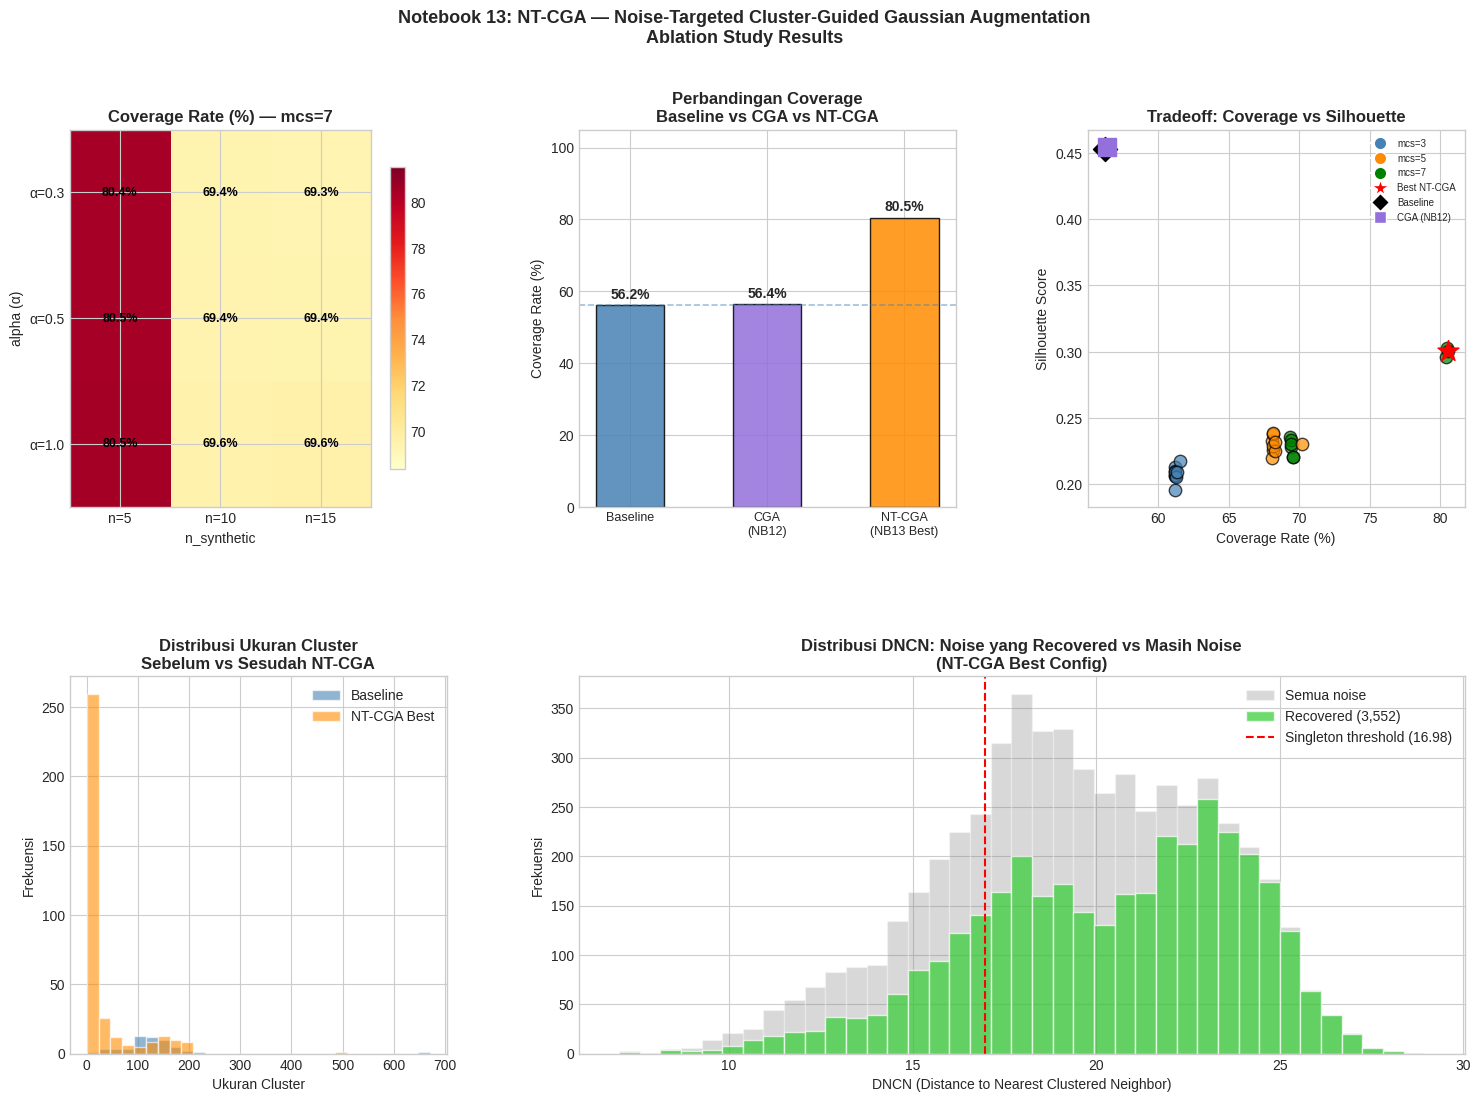

In [8]:
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])  # Heatmap coverage
ax2 = fig.add_subplot(gs[0, 1])  # Bar chart comparison
ax3 = fig.add_subplot(gs[0, 2])  # Coverage vs Silhouette scatter
ax4 = fig.add_subplot(gs[1, 0])  # Distribusi ukuran cluster
ax5 = fig.add_subplot(gs[1, 1:]) # DNCN distribution — recovered vs noise

# Pilih mcs terbaik untuk heatmap
best_mcs_for_heatmap = int(best_cov['mcs_recluster'])
df_heatmap = df_valid[df_valid['mcs_recluster'] == best_mcs_for_heatmap].copy()

# ── Panel 1: Heatmap Coverage (mcs = best) ────────────────────────
if len(df_heatmap) > 0:
    pivot_cov = df_heatmap.pivot(index='alpha', columns='n_synthetic', values='coverage') * 100
    im = ax1.imshow(pivot_cov.values, cmap='YlOrRd', aspect='auto',
                    vmin=pivot_cov.values.min() - 1, vmax=pivot_cov.values.max() + 1)
    ax1.set_xticks(range(len(pivot_cov.columns)))
    ax1.set_xticklabels([f'n={v}' for v in pivot_cov.columns])
    ax1.set_yticks(range(len(pivot_cov.index)))
    ax1.set_yticklabels([f'α={v}' for v in pivot_cov.index])
    ax1.set_title(f'Coverage Rate (%) — mcs={best_mcs_for_heatmap}', fontweight='bold')
    ax1.set_xlabel('n_synthetic')
    ax1.set_ylabel('alpha (α)')
    for i in range(len(pivot_cov.index)):
        for j in range(len(pivot_cov.columns)):
            val = pivot_cov.values[i, j]
            ax1.text(j, i, f'{val:.1f}%', ha='center', va='center',
                     color='black', fontsize=9, fontweight='bold')
    plt.colorbar(im, ax=ax1, shrink=0.8)

# ── Panel 2: Bar Chart — Baseline vs CGA (NB12) vs NT-CGA ─────────
methods       = ['Baseline', 'CGA\n(NB12)', 'NT-CGA\n(NB13 Best)']
coverages     = [coverage_base * 100, 56.4, best_cov_val * 100]   # NB12 best = 56.4%
noises        = [(1 - coverage_base) * 100, 43.6, (1 - best_cov_val) * 100]
colors_bar    = ['steelblue', 'mediumpurple', 'darkorange']
x_bar         = np.arange(len(methods))

bars = ax2.bar(x_bar, coverages, 0.5, color=colors_bar, edgecolor='black', alpha=0.85)
ax2.axhline(coverage_base * 100, color='steelblue', linestyle='--', linewidth=1.2,
            alpha=0.5, label='Baseline level')
ax2.set_xticks(x_bar)
ax2.set_xticklabels(methods, fontsize=9)
ax2.set_ylabel('Coverage Rate (%)')
ax2.set_title('Perbandingan Coverage\nBaseline vs CGA vs NT-CGA', fontweight='bold')
ax2.set_ylim(0, 105)
for bar, val in zip(bars, coverages):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── Panel 3: Coverage vs Silhouette Scatter ────────────────────────
cmap_mcs = {3: 'steelblue', 5: 'darkorange', 7: 'green'}
for _, row in df_valid.iterrows():
    c = cmap_mcs.get(int(row['mcs_recluster']), 'gray')
    ax3.scatter(row['coverage'] * 100, row['silhouette'],
                color=c, s=80, edgecolors='black', zorder=3, alpha=0.7)

ax3.scatter(best_cov_val * 100, best_sil_val,
            s=250, marker='*', color='red', zorder=5, label='Best NT-CGA')
# Baseline reference
ax3.scatter(coverage_base * 100, 0.4530,
            s=150, marker='D', color='black', zorder=5, label='Baseline')
ax3.scatter(56.4, 0.4547,
            s=150, marker='s', color='mediumpurple', zorder=5, label='CGA (NB12)')

from matplotlib.lines import Line2D
legend_elements = (
    [Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
            markersize=9, label=f'mcs={m}') for m, c in cmap_mcs.items()] +
    [Line2D([0], [0], marker='*', color='w', markerfacecolor='red', markersize=13, label='Best NT-CGA'),
     Line2D([0], [0], marker='D', color='w', markerfacecolor='black', markersize=9, label='Baseline'),
     Line2D([0], [0], marker='s', color='w', markerfacecolor='mediumpurple', markersize=9, label='CGA (NB12)')]
)
ax3.legend(handles=legend_elements, fontsize=7, loc='best')
ax3.set_xlabel('Coverage Rate (%)')
ax3.set_ylabel('Silhouette Score')
ax3.set_title('Tradeoff: Coverage vs Silhouette', fontweight='bold')

# ── Panel 4: Distribusi Ukuran Cluster ────────────────────────────
sizes_base_vals = [v for k, v in Counter(labels_baseline).items() if k != -1]
sizes_best_vals = [v for k, v in Counter(labels_best).items() if k != -1]
max_size = max(max(sizes_base_vals), max(sizes_best_vals)) + 10
bins = np.linspace(0, max_size, 30)
ax4.hist(sizes_base_vals, bins=bins, alpha=0.6, label='Baseline', color='steelblue', edgecolor='white')
ax4.hist(sizes_best_vals, bins=bins, alpha=0.6, label='NT-CGA Best', color='darkorange', edgecolor='white')
ax4.set_xlabel('Ukuran Cluster')
ax4.set_ylabel('Frekuensi')
ax4.set_title('Distribusi Ukuran Cluster\nSebelum vs Sesudah NT-CGA', fontweight='bold')
ax4.legend()

# ── Panel 5: DNCN Distribution — Recovered vs Still Noise ─────────
dncn_all   = dncn_distances                           # semua noise
dncn_recovered = dncn_distances[                      # noise yang berhasil di-cluster
    recovered_mask[noise_mask]
] if noise_recovered > 0 else np.array([])
dncn_still  = dncn_distances[still_noise[noise_mask]] if still_noise.sum() > 0 else np.array([])

bins_dncn = np.linspace(dncn_all.min(), dncn_all.max(), 40)
ax5.hist(dncn_all, bins=bins_dncn, alpha=0.3, label='Semua noise', color='gray', edgecolor='white')
if len(dncn_recovered) > 0:
    ax5.hist(dncn_recovered, bins=bins_dncn, alpha=0.7,
             label=f'Recovered ({len(dncn_recovered):,})', color='limegreen', edgecolor='white')
ax5.axvline(Config.DNCN_Q25, color='red', linestyle='--', linewidth=1.5,
            label=f'Singleton threshold ({Config.DNCN_Q25})')
ax5.set_xlabel('DNCN (Distance to Nearest Clustered Neighbor)')
ax5.set_ylabel('Frekuensi')
ax5.set_title('Distribusi DNCN: Noise yang Recovered vs Masih Noise\n(NT-CGA Best Config)', fontweight='bold')
ax5.legend()

fig.suptitle(
    'Notebook 13: NT-CGA — Noise-Targeted Cluster-Guided Gaussian Augmentation\nAblation Study Results',
    fontsize=13, fontweight='bold'
)

plot_path = f"{Config.PLOTS_DIR}notebook13_ntcga_results.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"💾 Plot disimpan: {plot_path}")
plt.show()

## Cell 9 — Summary & Simpan Hasil

In [9]:
print("=" * 70)
print("📋 NOTEBOOK 13 — SUMMARY NT-CGA")
print("=" * 70)

print(f"""
┌──────────────────────────────────────────────────────────────────────┐
│         NOISE-TARGETED CGA (NT-CGA) — RINGKASAN EKSPERIMEN          │
├──────────────────────────────────────────────────────────────────────┤
│                                                                      │
│  DATASET:                                                            │
│  • Total embeddings asli   : {len(embeddings):,}                          │
│  • Total noise baseline    : {n_noise_base:,} (43.8%)                    │
│  • Probable singletons     : {n_sing:,} ({n_sing/n_noise_base:.1%} dari noise)               │
│  • DNCN threshold          : < {Config.DNCN_Q25} (Q25 NB11)               │
│                                                                      │
│  ABLATION STUDY:                                                     │
│  • α values         : {Config.ALPHA_LIST}                    │
│  • n_syn values     : {Config.N_SYNTHETIC_LIST}                          │
│  • mcs_recluster    : {Config.MCS_RECLUSTER_LIST}                          │
│  • Total kombinasi  : {total_combos}                                   │
│                                                                      │
│  KONFIGURASI TERBAIK (by coverage):                                  │
│  • α={best_alpha}, n_synthetic={best_n_syn}, mcs_recluster={best_mcs_r}                 │
│  • Synthetic gen: {best_syn_gen:,}                               │
│                                                                      │
│  PERBANDINGAN HASIL:                                                 │
│  ┌─────────────────┬─────────────┬─────────────┬──────────────────┐ │
│  │ Metric          │  Baseline   │ CGA (NB12)  │  NT-CGA (NB13)  │ │
│  ├─────────────────┼─────────────┼─────────────┼──────────────────┤ │
│  │ Clusters        │ {n_clusters_base:<11} │ {54:<11} │ {best_nclu:<16} │ │
│  │ Noise           │ {n_noise_base:<11,} │ {5544:<11,} │ {best_nnoise:<16,} │ │
│  │ Coverage        │ {coverage_base:<11.1%} │ {'56.4%':<11} │ {best_cov_val:<16.1%} │ │
│  │ Silhouette      │ 0.4530      │ 0.4547      │ {best_sil_val:<16.4f} │ │
│  │ Δ Coverage      │ —           │ +0.2%       │ {delta_cov:<+16.1%} │ │
│  └─────────────────┴─────────────┴─────────────┴──────────────────┘ │
└──────────────────────────────────────────────────────────────────────┘
""")

# ── Simpan hasil ─────────────────────────────────────────────────────
save_data = {
    'timestamp'             : datetime.now().isoformat(),
    'notebook'              : 'Notebook 13: NT-CGA — Noise-Targeted CGA',
    'n_total_embeddings'    : len(embeddings),
    'n_noise_baseline'      : n_noise_base,
    'n_clusters_baseline'   : n_clusters_base,
    'coverage_baseline'     : coverage_base,
    'n_singletons'          : n_sing,
    'dncn_q25_threshold'    : Config.DNCN_Q25,
    'k_neighbors'           : Config.K_NEIGHBORS,
    'ablation_results'      : [{
        'alpha'             : r['alpha'],
        'n_synthetic'       : r['n_synthetic'],
        'mcs_recluster'     : r['mcs_recluster'],
        'n_syn_gen'         : r['n_syn_gen'],
        'n_clusters'        : r['n_clusters'],
        'n_noise'           : r['n_noise'],
        'coverage'          : r['coverage'],
        'silhouette'        : r['silhouette'],
        'elapsed_s'         : r['elapsed_s'],
    } for r in ablation_results],
    'best_alpha'            : best_alpha,
    'best_n_synthetic'      : best_n_syn,
    'best_mcs_recluster'    : best_mcs_r,
    'best_labels'           : labels_best,
    'best_coverage'         : best_cov_val,
    'best_silhouette'       : best_sil_val,
    'best_n_clusters'       : best_nclu,
    'best_n_noise'          : best_nnoise,
    'noise_recovered'       : noise_recovered,
    'delta_coverage'        : delta_cov,
    'delta_clusters'        : delta_clusters,
    'gpu_seed'              : Config.SEED,
}

pkl_path = f"{Config.RESULTS_DIR}notebook13_ntcga_results.pkl"
with open(pkl_path, 'wb') as f:
    pickle.dump(save_data, f)

print(f"💾 Hasil disimpan: {pkl_path}")
print()
print("=" * 70)
print("✅ Notebook 13 selesai. NT-CGA results siap untuk Final Comparison.")
print("=" * 70)

del embeddings_gpu
cp.get_default_memory_pool().free_all_blocks()
print("\n🧹 GPU memory dibersihkan.")

📋 NOTEBOOK 13 — SUMMARY NT-CGA

┌──────────────────────────────────────────────────────────────────────┐
│         NOISE-TARGETED CGA (NT-CGA) — RINGKASAN EKSPERIMEN          │
├──────────────────────────────────────────────────────────────────────┤
│                                                                      │
│  DATASET:                                                            │
│  • Total embeddings asli   : 12,715                          │
│  • Total noise baseline    : 5,565 (43.8%)                    │
│  • Probable singletons     : 1,395 (25.1% dari noise)               │
│  • DNCN threshold          : < 16.98 (Q25 NB11)               │
│                                                                      │
│  ABLATION STUDY:                                                     │
│  • α values         : [0.3, 0.5, 1.0]                    │
│  • n_syn values     : [5, 10, 15]                          │
│  • mcs_recluster    : [3, 5, 7]                          │
│  •